# Линейная регрессия


Линейные методы предполагают, что между признаками объекта и целевой переменной существует линейная зависимость, то есть:
$$ \hat{y} = w_1 x_1 + w_2 x_2 + ... + w_k x_k + b,$$
где $\hat{y}$ - целевая переменная (что мы хотим предсказать), $x_i$ - i-ый признак объекта $x$, $w_i$ - вес $i$-го признака, $b$ - bias (смещение, свободный член).

В задаче линейной регрессии $\hat{y}$ - это действительное число.

Часто для упрощения записи вводят дополнительный фиктивный признак $x_0$, который всегда равен 1, тогда bias - вес этого признака. В этом случае формула может быть записана как скалярное произведение:
$$ \hat{y} = <w, x> $$

В матричной форме формулу можно переписать следующим образом:
$$ \hat{y} = Xw,$$
$\hat{y}$ - вектор значений целевой переменной размера $n$, $X$ - матрица значений признаков объектов размера $n \times k$, w - вектор весов размера $k$. То есть в наших данных имеется $n$ объектов, каждый их которых описан $k$ признаками.

Таким образом, в матричной форме модель задаётся следующим образом:
$$ y = Xw + \epsilon$$

Важно отметить, что параметрами этой модели являются веса $w$. Когда говорят об обучении какого-либо алгоритма машинного обучения, как правило, имеют в виду настройку весов, т.е. параметров модели.  

На практике $\hat{y} $ может отличается от реальных значений, которые принимает целевая переменная $y$. Разницу между реальным значением и предсказанным, обозначим как $\epsilon$ - вектор значений случайной переменной, соответствующая случайной, непрогнозируемой ошибке модели. Ограничения, которые накладываются на эту модель:
* математическое ожидание случайных ошибок $\epsilon$ равно нулю,
* дисперсия случайных ошибок одинакова и конечна,
* случайные ошибки не скоррелированы.

Один из способов вычислить значения параметров модели, давно знаком - это наименьших квадратов, который минимизирует среднеквадратичную ошибку между реальным значением зависимой переменной и прогнозом, выданным моделью. Решение по методу наименьших квадратов дает:
$$ w = (X^TX)^{-1}X^TY $$

Загрузим необходимые библиотеки

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

## Оценка результатов

Чтобы оценить качество работы алгоритма нам необходимо применяют разные метрики. Наиболее частые метрики средневадратичная и средняя абсолютная ошибки. Вычислим эти метрики на обучающей и на тестовой выборках.

 * *mean_absolute_error* - средняя абсолютная ошибка $|y_i - \hat{y}_i|$
 * *mean_squared_error* - средняя квадратичная ошибка $(y_i - \hat{y}_i)^2$

## Задание 3.1

Пример 1. Сгенерируем искусственные данные. Сначала поработаем с простейшим одномерным случаем, когда у нас значение $y$ будет зависеть только от одного значения $x$.




In [ ]:
def generate_data(n_points=20):
  """
    Принимает на вход n_points точек
    Возвращает данные для обучения и теста
  """
  X = np.linspace(-5, 5, n_points)
  y = 10 * X - 7

  X_train = X[0::2].reshape(-1, 1)
  y_train = y[0::2] + np.random.randn(int(n_points/2)) * 10

  X_test = X[1::2].reshape(-1, 1)
  y_test = y[1::2] + np.random.randn(int(n_points/2)) * 10

  print(f'Generated {len(X_train)} train samples and {len(X_test)} test samples')
  return X, X_train, y_train, X_test, y_test

In [ ]:
X, X_train, y_train, X_test, y_test = generate_data(100)

Generated 50 train samples and 50 test samples


Своя реализация (МНК):
  w = [10.42364463]  b = -7.748
  MAE : 9.577
  MSE : 140.883

sklearn LinearRegression:
  w = [10.42364463]  b = -7.748
  MAE : 9.577
  MSE : 140.883


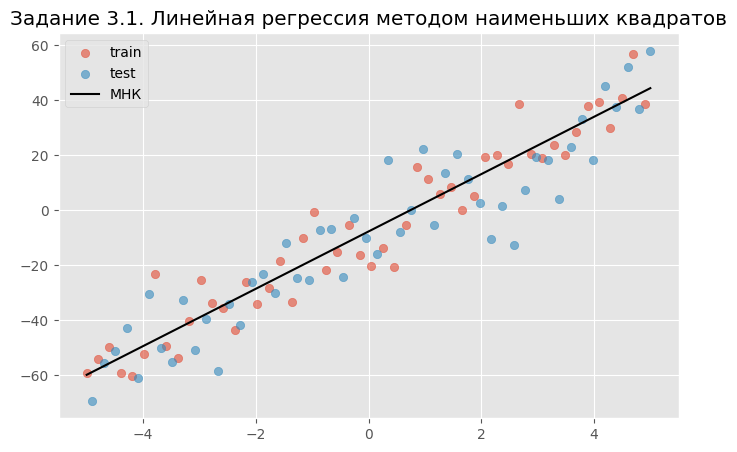

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


def ols_fit(X, y):
    X_ext = np.hstack([np.ones((X.shape[0], 1)), X])
    w_full = np.linalg.inv(X_ext.T @ X_ext) @ X_ext.T @ y
    b = w_full[0]
    w = w_full[1:]
    return w, b


def ols_predict(X, w, b):
    return X @ w + b


w, b = ols_fit(X_train, y_train)
y_pred_test = ols_predict(X_test, w, b)

print("Своя реализация (МНК):")
print("  w =", w, " b =", round(b, 3))
print("  MAE :", round(mean_absolute_error(y_test, y_pred_test), 3))
print("  MSE :", round(mean_squared_error(y_test, y_pred_test), 3))

sk = LinearRegression().fit(X_train, y_train)
y_pred_sk = sk.predict(X_test)
print("\nsklearn LinearRegression:")
print("  w =", sk.coef_, " b =", round(sk.intercept_, 3))
print("  MAE :", round(mean_absolute_error(y_test, y_pred_sk), 3))
print("  MSE :", round(mean_squared_error(y_test, y_pred_sk), 3))

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, label="train", alpha=0.6)
plt.scatter(X_test, y_test, label="test", alpha=0.6)
order = np.argsort(X.ravel())
plt.plot(X[order], ols_predict(X.reshape(-1, 1), w, b)[order], color="black", label="МНК")
plt.legend()
plt.title("Задание 3.1. Линейная регрессия методом наименьших квадратов")
plt.show()

## Задание 3.2

Пример 2. Не всегда в задаче регрессии в качестве решения выступает прямая, как в предыдущем случае. Рассмотрим ещё один пример, в котором у объектов всё ещё один признак. Но теперь мы будм брать случайную точку на синусоиде и добавлять к ней шум — таким образом получим целевую переменную, признаком в этом случае будет координата $x$.

In [ ]:
def generate_wave_set(n_support=1000, n_train=25, std=0.3):
    data = {}
    # выберем некоторое количество точек из промежутка от 0 до 2*pi
    data['support'] = np.linspace(0, 2*np.pi, num=n_support)
    # для каждой посчитаем значение sin(x) + 1
    # это будет ground truth
    data['values'] = np.sin(data['support']) + 1
    # из support посемплируем некоторое количество точек с возвратом, это будут признаки
    data['x_train'] = np.sort(np.random.choice(data['support'], size=n_train, replace=True))
    # опять посчитаем sin(x) + 1 и добавим шум, получим целевую переменную
    data['y_train'] = np.sin(data['x_train']) + 1 + np.random.normal(0, std, size=data['x_train'].shape[0])
    return data

data = generate_wave_set(1000, 250)

Прямая на синусоиде (МНК):
  MAE : 0.463
  MSE : 0.2973


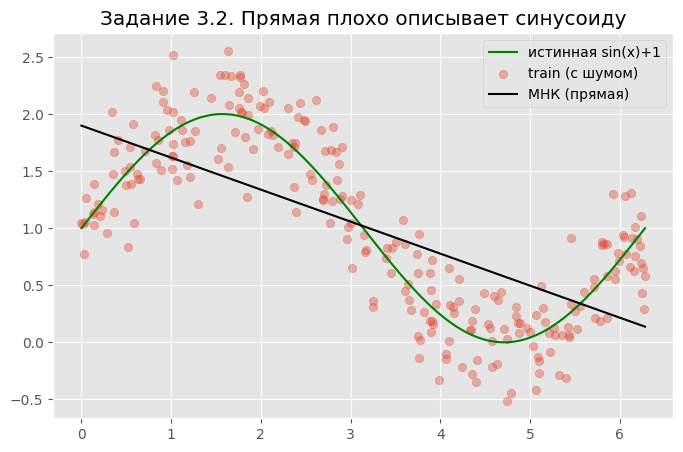

In [ ]:
x_wave = data['x_train'].reshape(-1, 1)
y_wave = data['y_train']

w_w, b_w = ols_fit(x_wave, y_wave)
y_wave_pred = ols_predict(x_wave, w_w, b_w)

print("Прямая на синусоиде (МНК):")
print("  MAE :", round(mean_absolute_error(y_wave, y_wave_pred), 4))
print("  MSE :", round(mean_squared_error(y_wave, y_wave_pred), 4))

plt.figure(figsize=(8, 5))
plt.plot(data['support'], data['values'], label="истинная sin(x)+1", color="green")
plt.scatter(data['x_train'], data['y_train'], label="train (с шумом)", alpha=0.4)
xs = np.linspace(0, 2 * np.pi, 200).reshape(-1, 1)
plt.plot(xs, ols_predict(xs, w_w, b_w), color="black", label="МНК (прямая)")
plt.legend()
plt.title("Задание 3.2. Прямая плохо описывает синусоиду")
plt.show()

Конечно, такое решение нас вряд ли может устроить. Нужно применить полинимиальную регрессию. Идея здесь такая. Каждый признак в исходную формулу может входить не только в первой степени, но и во второй, в третьей и так далее. То есть для случая, когда у нас только один признак:
$$ \widehat{y} = w_1 x_1 + w_2 x_1^2 + ... + w_k x_1^k + b,$$

## Задание 3.3

Степень | MSE на train
    1   | 0.2973
    3   | 0.0916
    5   | 0.0816
    9   | 0.0768
   15   | 38.7710


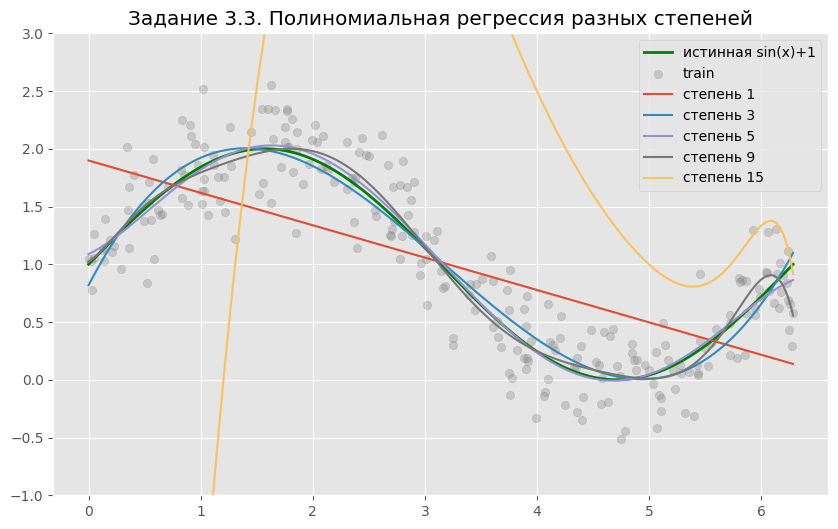

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

degrees = [1, 3, 5, 9, 15]
xs = np.linspace(0, 2 * np.pi, 300).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.plot(data['support'], data['values'], label="истинная sin(x)+1", color="green", linewidth=2)
plt.scatter(data['x_train'], data['y_train'], label="train", alpha=0.3, color="gray")

print("Степень | MSE на train")
for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(x_wave)
    w_poly, b_poly = ols_fit(X_poly[:, 1:], y_wave)
    train_pred = ols_predict(X_poly[:, 1:], w_poly, b_poly)
    mse = mean_squared_error(y_wave, train_pred)
    print(f"   {d:>2}   | {mse:.4f}")

    xs_poly = poly.transform(xs)[:, 1:]
    plt.plot(xs, ols_predict(xs_poly, w_poly, b_poly), label=f"степень {d}")

plt.ylim(-1, 3)
plt.legend()
plt.title("Задание 3.3. Полиномиальная регрессия разных степеней")
plt.show()

**Вывод по 3.3.** Полином степени 1 (прямая) недообучается — не повторяет изгиб синусоиды. Степени 3–5 описывают форму лучше всего: кривая повторяет один период синуса без лишних колебаний. Слишком высокие степени (9, 15) начинают переобучаться — изгибаются под шум в данных, особенно по краям интервала. Оптимальный компромисс — степень около 3–5.

# Реальный датасет

Возьмём реальный набор данных Boston из sklearn.datasets. Этот датасет описывает средние цены на недвижимость в районах Бостона в тысячах долларов.

Примеры признаков объектов недвижимости: количество преступлений на душу населения, процент старых домов в районе, количество учеников на одного учителя и т.д. Обратите внимание на то, что данные уже оцифрованы там, где изначально признаки были качественными.

Загрузим датасет, выведем информацию

In [11]:
from sklearn.datasets import load_boston

ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

Возьмите датасет отсюда: https://www.kaggle.com/datasets/vikrishnan/boston-house-prices/

In [ ]:
house_data = load_boston()

## Задание 3.4

In [12]:
from sklearn.model_selection import train_test_split

columns = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
           "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]

boston = pd.read_csv("housing.csv", header=None, delimiter=r"\s+", names=columns)

X_full = boston.drop(columns=["MEDV"])
y_boston = boston["MEDV"]

corr = boston.corr()["MEDV"].drop("MEDV").abs().sort_values(ascending=False)
print("Корреляция признаков с ценой (MEDV):")
print(corr.round(3))

top7 = corr.head(7).index.tolist()
print("\n7 наиболее значимых признаков:", top7)

X_top = X_full[top7]


def eval_dataset(X, y, title):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)
    model = LinearRegression().fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae = mean_absolute_error(y_te, pred)
    mse = mean_squared_error(y_te, pred)
    print(f"{title}: MAE = {mae:.3f}, MSE = {mse:.3f}")
    return mae, mse


print()
eval_dataset(X_full, y_boston, "Полный датасет (13 признаков)")
eval_dataset(X_top, y_boston, "Усечённый (7 признаков) ")

Корреляция признаков с ценой (MEDV):
LSTAT      0.738
RM         0.695
PTRATIO    0.508
INDUS      0.484
TAX        0.469
NOX        0.427
CRIM       0.388
RAD        0.382
AGE        0.377
ZN         0.360
B          0.333
DIS        0.250
CHAS       0.175
Name: MEDV, dtype: float64

7 наиболее значимых признаков: ['LSTAT', 'RM', 'PTRATIO', 'INDUS', 'TAX', 'NOX', 'CRIM']

Полный датасет (13 признаков): MAE = 3.061, MSE = 22.099
Усечённый (7 признаков) : MAE = 3.414, MSE = 26.399


(3.4144092734051674, 26.39887698982118)